# Weather Precipitation Prediction using Machine Learning

## Project Overview

Weather prediction is an important application of data science. In this project, historical weather observations are analyzed to predict **precipitation type (rain or snow)** using machine learning techniques.

The objective is to build a classification model that predicts precipitation type based on meteorological variables such as:

- temperature
- humidity
- pressure
- wind speed
- visibility

This notebook demonstrates a complete machine learning workflow including:

- Data loading and inspection
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Handling class imbalance
- Model training and comparison
- Hyperparameter tuning
- Model evaluation
- Feature importance analysis

Dataset: `weatherHistory.csv`

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

## Load the Dataset

In [3]:
df = pd.read_csv("weatherHistory.csv")

df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


### Correcting the typo

In [4]:
df = df.rename(columns={"Loud Cover": "Cloud Cover"})

## Dataset Shape

In [5]:
df.shape

(96453, 12)

The dataset contains 96,453 weather observations with 12 variables describing meteorological conditions.

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Cloud Cover               96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


## Handling Missing Values

In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Cloud Cover                   0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

## Data Cleaning

Some columns in the dataset are not useful for machine learning models, such as text summaries or timestamps. We remove these columns to focus only on relevant predictive features.

In [8]:
df = df.drop(columns=[
    "Formatted Date",
    "Daily Summary",
    "Summary"
], errors="ignore")

df = df.dropna()

df.head()

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Cloud Cover,Pressure (millibars)
0,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13
1,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63
2,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94
3,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41
4,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset and identify relationships between variables before training machine learning models.

## Distribution of Precipitation Type

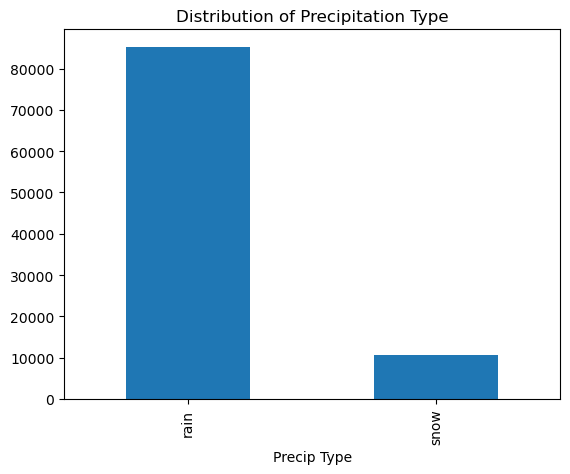

In [9]:
plt.figure()

df["Precip Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Precipitation Type")

plt.show()

## Correlation Matrix

A correlation heatmap helps identify relationships between numerical variables.

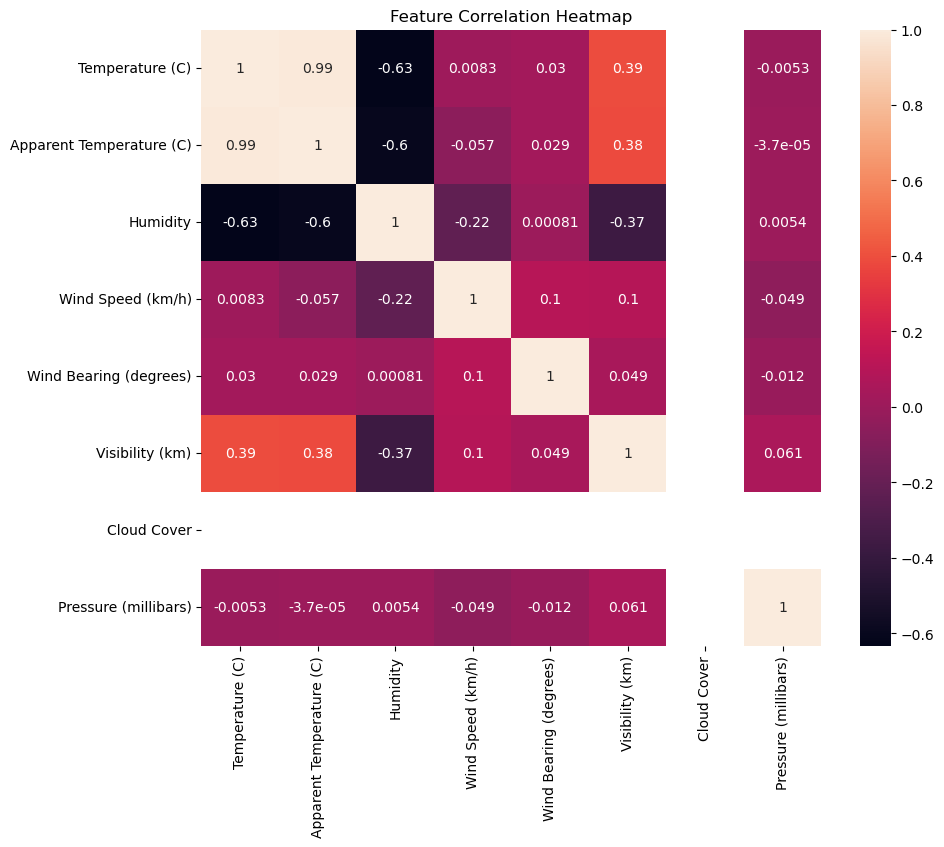

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

## Temperature vs Humidity

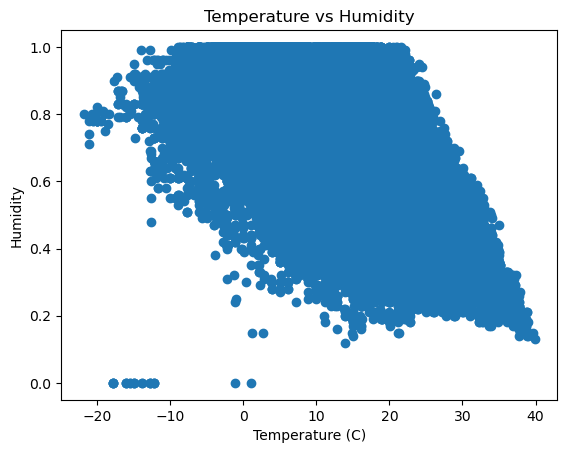

In [11]:
plt.figure()

plt.scatter(df["Temperature (C)"], df["Humidity"])

plt.xlabel("Temperature (C)")
plt.ylabel("Humidity")

plt.title("Temperature vs Humidity")

plt.show()

# Feature Engineering

Feature engineering involves creating new variables that may improve model performance.

In [12]:
df["Temp_Humidity_Index"] = df["Temperature (C)"] * df["Humidity"]

df.head()

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Cloud Cover,Pressure (millibars),Temp_Humidity_Index
0,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,8.430278
1,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,8.045778
2,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,8.346222
3,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,6.879778
4,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,7.267111


# Prepare Data for Machine Learning

In [13]:
X = df.drop("Precip Type", axis=1)

y = df["Precip Type"]

## Convert Categorical Variables

In [14]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Cloud Cover,Pressure (millibars),Temp_Humidity_Index
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,8.430278
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,8.045778
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,8.346222
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,6.879778
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,7.267111


## Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Handle Class Imbalance using SMOTE

In [17]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

pd.Series(y_train_resampled).value_counts()

Precip Type
rain    68178
snow    68178
Name: count, dtype: int64

# Model Training and Comparison

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train_resampled, y_train_resampled)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

results

{'Logistic Regression': 0.9906712528663748,
 'Decision Tree': 1.0,
 'Random Forest': 0.9999478840942255,
 'Gradient Boosting': 1.0}

## Model Accuracy Comparison

In [19]:
pd.Series(results).sort_values(ascending=False)

Decision Tree          1.000000
Gradient Boosting      1.000000
Random Forest          0.999948
Logistic Regression    0.990671
dtype: float64

# Hyperparameter Tuning (Random Forest)

In [20]:
rf = RandomForestClassifier()

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5
)

grid.fit(X_train_resampled, y_train_resampled)

grid.best_params_

{'max_depth': None, 'n_estimators': 100}

# Final Model Evaluation

In [21]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9999478840942255


## Classification Report

In [22]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

        rain       1.00      1.00      1.00     17046
        snow       1.00      1.00      1.00      2142

    accuracy                           1.00     19188
   macro avg       1.00      1.00      1.00     19188
weighted avg       1.00      1.00      1.00     19188



## Confusion Matrix

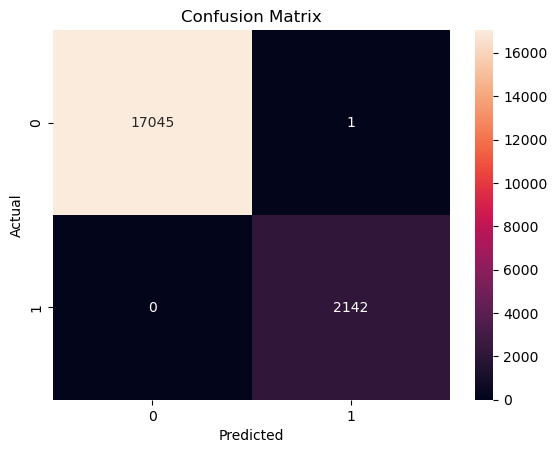

In [23]:
cm = confusion_matrix(y_test, predictions)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

# Feature Importance Analysis

Feature importance helps identify which variables contribute most to predicting precipitation type.

In [24]:
importances = best_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
8,Temp_Humidity_Index,0.408433
0,Temperature (C),0.361729
1,Apparent Temperature (C),0.171943
5,Visibility (km),0.028968
7,Pressure (millibars),0.019037
2,Humidity,0.008812
3,Wind Speed (km/h),0.001062
4,Wind Bearing (degrees),0.000016
6,Cloud Cover,0.000000


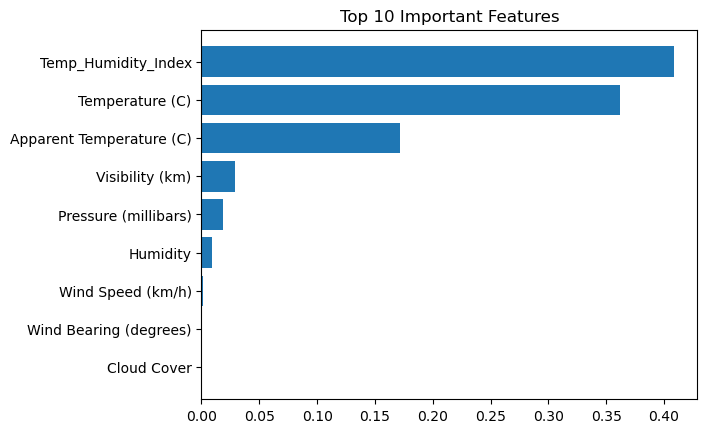

In [25]:
plt.figure()

plt.barh(
    importance_df["Feature"].head(10),
    importance_df["Importance"].head(10)
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Key Findings

- Temperature and humidity show strong relationships with precipitation type.
- Handling class imbalance using SMOTE helped balance the training dataset.
- Tree-based models such as Random Forest and Gradient Boosting achieved the best performance because they are effective at capturing non-linear relationships between meteorological variables.

The extremely high accuracy observed in this project is likely due to strong relationships between temperature and precipitation type. For example, snow typically occurs at lower temperatures, making the classification problem relatively easier for machine learning models.

## Limitations

While the models achieved very high accuracy (~99–100%), several limitations should be considered when interpreting the results.

**1. Strong Relationship Between Temperature and Precipitation**

Precipitation type is highly influenced by temperature. Snow typically occurs at lower temperatures while rain occurs at higher temperatures. Because of this strong relationship, machine learning models can classify precipitation types with very high accuracy using temperature-related variables.

**2. Feature Redundancy**

Some variables in the dataset are closely related, such as Temperature, Apparent Temperature, and the engineered Temperature-Humidity Index. These variables may contain overlapping information that could influence model behavior.

**3. Limited Geographic Scope**

The dataset contains weather observations from a single location (Szeged, Hungary). As a result, the trained model may not generalize well to weather patterns in other geographic regions.

**4. Simplified Prediction Task**

The near-perfect accuracy achieved by several models suggests that the classification problem may be relatively simple for machine learning models due to strong relationships between the available features and the target variable.

# Conclusion

This project demonstrated a complete machine learning workflow for predicting precipitation type using historical weather data.

Key steps included:

- data preprocessing
- exploratory data analysis
- feature engineering
- model comparison
- hyperparameter tuning
- model evaluation
- feature importance analysis